In [9]:
# Core libraries
suppressPackageStartupMessages({
  library(ggplot2)
  library(dplyr)
  library(gridExtra)
  library(coda)
  library(xtable)
})

set.seed(432)

dir.create("results", showWarnings = FALSE)
dir.create("results/figs", showWarnings = FALSE)
dir.create("results/tables", showWarnings = FALSE)

In [11]:
# Load data
diabetes <- read.csv("diabetes.csv")

print(names(diabetes))
cat("\nDataset Summary:\n")
print(summary(diabetes))

diabetes_clean <- diabetes %>%
  filter(Glucose > 0,
         BMI > 0,
         BloodPressure > 0) %>%
  mutate(
    Outcome = factor(Outcome,
                     levels = c(0, 1),
                     labels = c("No Diabetes", "Diabetes"))
  )

print(summary(diabetes_clean))

[1] "Pregnancies"              "Glucose"                 
[3] "BloodPressure"            "SkinThickness"           
[5] "Insulin"                  "BMI"                     
[7] "DiabetesPedigreeFunction" "Age"                     
[9] "Outcome"                 

Dataset Summary:
  Pregnancies        Glucose      BloodPressure    SkinThickness  
 Min.   : 0.000   Min.   :  0.0   Min.   :  0.00   Min.   : 0.00  
 1st Qu.: 1.000   1st Qu.: 99.0   1st Qu.: 62.00   1st Qu.: 0.00  
 Median : 3.000   Median :117.0   Median : 72.00   Median :23.00  
 Mean   : 3.845   Mean   :120.9   Mean   : 69.11   Mean   :20.54  
 3rd Qu.: 6.000   3rd Qu.:140.2   3rd Qu.: 80.00   3rd Qu.:32.00  
 Max.   :17.000   Max.   :199.0   Max.   :122.00   Max.   :99.00  
    Insulin           BMI        DiabetesPedigreeFunction      Age       
 Min.   :  0.0   Min.   : 0.00   Min.   :0.0780           Min.   :21.00  
 1st Qu.:  0.0   1st Qu.:27.30   1st Qu.:0.2437           1st Qu.:24.00  
 Median : 30.5   Median :32.

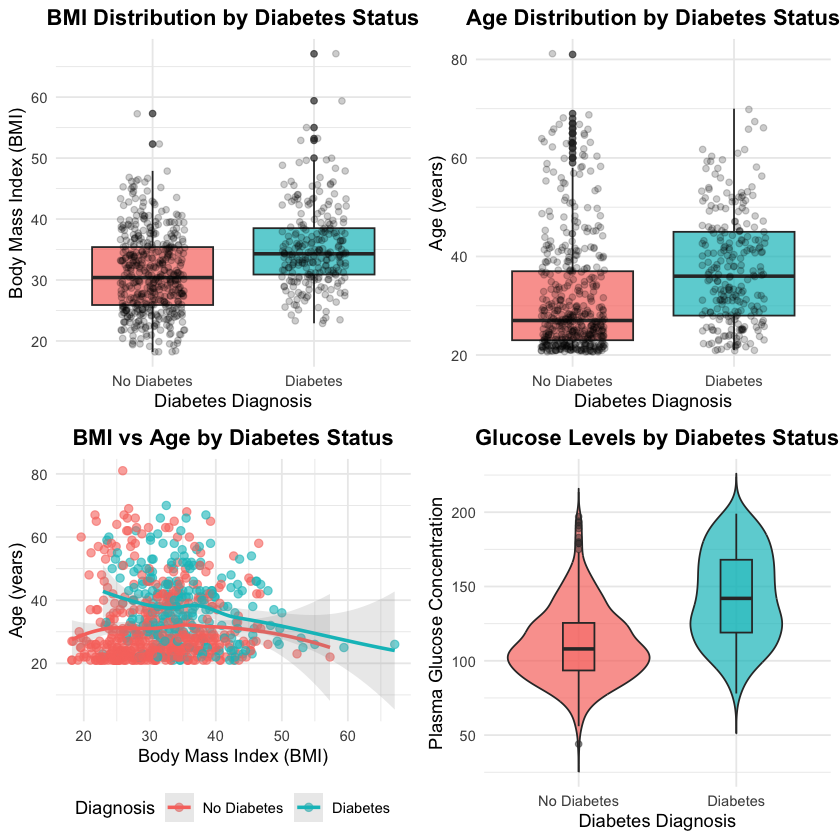

In [23]:
# EDA
suppressMessages({
  plot1 <- ggplot(diabetes_clean,
                  aes(x = Outcome, y = BMI, fill = Outcome)) +
    geom_boxplot(alpha = 0.7) +
    geom_jitter(alpha = 0.2, width = 0.2) +
    labs(title = "BMI Distribution by Diabetes Status",
         x = "Diabetes Diagnosis",
         y = "Body Mass Index (BMI)") +
    theme_minimal() +
    theme(
      legend.position = "none",
      plot.title = element_text(hjust = 0.5, face = "bold")
    )
  
  plot2 <- ggplot(diabetes_clean,
                  aes(x = Outcome, y = Age, fill = Outcome)) +
    geom_boxplot(alpha = 0.7) +
    geom_jitter(alpha = 0.2, width = 0.2) +
    labs(title = "Age Distribution by Diabetes Status",
         x = "Diabetes Diagnosis",
         y = "Age (years)") +
    theme_minimal() +
    theme(
      legend.position = "none",
      plot.title = element_text(hjust = 0.5, face = "bold")
    )
  
  plot3 <- ggplot(diabetes_clean,
                  aes(x = BMI, y = Age, color = Outcome)) +
    geom_point(alpha = 0.6, size = 2) +
    geom_smooth(method = "loess", se = TRUE, alpha = 0.2) +
    labs(title = "BMI vs Age by Diabetes Status",
         x = "Body Mass Index (BMI)",
         y = "Age (years)",
         color = "Diagnosis") +
    theme_minimal() +
    theme(
      plot.title = element_text(hjust = 0.5, face = "bold"),
      legend.position = "bottom"
    )
  
  plot4 <- ggplot(diabetes_clean,
                  aes(x = Outcome, y = Glucose, fill = Outcome)) +
    geom_violin(alpha = 0.7, trim = FALSE) +
    geom_boxplot(width = 0.2, alpha = 0.5) +
    labs(title = "Glucose Levels by Diabetes Status",
         x = "Diabetes Diagnosis",
         y = "Plasma Glucose Concentration") +
    theme_minimal() +
    theme(
      legend.position = "none",
      plot.title = element_text(hjust = 0.5, face = "bold")
    )
  
  grid.arrange(plot1, plot2, plot3, plot4, ncol = 2)
  
  ggsave("results/figs/plot1_bmi_by_outcome.pdf", plot1, width = 6, height = 4)
  ggsave("results/figs/plot1_bmi_by_outcome.png", plot1, width = 6, height = 4, dpi = 300)
  
  ggsave("results/figs/plot2_age_by_outcome.pdf", plot2, width = 6, height = 4)
  ggsave("results/figs/plot2_age_by_outcome.png", plot2, width = 6, height = 4, dpi = 300)
  
  ggsave("results/figs/plot3_bmi_vs_age.pdf", plot3, width = 6, height = 4)
  ggsave("results/figs/plot3_bmi_vs_age.png", plot3, width = 6, height = 4, dpi = 300)
  
  ggsave("results/figs/plot4_glucose_by_outcome.pdf", plot4, width = 6, height = 4)
  ggsave("results/figs/plot4_glucose_by_outcome.png", plot4, width = 6, height = 4, dpi = 300)
  
})

In [14]:
# Prepare data

diabetes_model <- diabetes_clean %>%
  mutate(
    y = as.numeric(Outcome == "Diabetes"),
    z_glucose = as.numeric(scale(Glucose)),
    z_bmi = as.numeric(scale(BMI)),
    z_age = as.numeric(scale(Age)),
    z_bp = as.numeric(scale(BloodPressure))
  )

X <- model.matrix(
  y ~ z_glucose + z_bmi + z_age + z_bp,
  data = diabetes_model
)
y <- diabetes_model$y

n <- length(y)
p <- ncol(X)
colnames(X)

[1] "(Intercept)" "z_glucose"   "z_bmi"       "z_age"       "z_bp"

In [15]:
# Log-posterior for logistic regression

log_post <- function(beta, X, y) {
  eta <- as.vector(X %*% beta)
  loglik <- sum(y * eta - log1p(exp(eta)))
  
  lp_intercept <- dnorm(beta[1], mean = 0, sd = 5, log = TRUE)
  lp_slopes <- sum(dnorm(beta[-1], mean = 0, sd = 2.5, log = TRUE))
  
  loglik + lp_intercept + lp_slopes
}

In [16]:
# Random-walk Metropolis sampler

rw_metropolis <- function(start, n_iter, proposal_sd, X, y) {
  p <- length(start)
  beta_current <- start
  lp_current <- log_post(beta_current, X, y)
  
  chain <- matrix(NA, nrow = n_iter, ncol = p)
  acc <- 0
  
  for (t in 1:n_iter) {
    beta_prop <- rnorm(p, mean = beta_current, sd = proposal_sd)
    
    lp_prop <- log_post(beta_prop, X, y)
    log_alpha <- lp_prop - lp_current
    
    if (log(runif(1)) < log_alpha) {
      beta_current <- beta_prop
      lp_current <- lp_prop
      acc <- acc + 1
    }
    
    chain[t, ] <- beta_current
  }
  
  list(
    chain = chain,
    accept_rate  = acc / n_iter
  )
}

In [17]:
# Run the chain

start_vals  <- rep(0, p)
n_iter <- 30000
proposal_sd <- 0.12

fit <- rw_metropolis(
  start = start_vals,
  n_iter = n_iter,
  proposal_sd = proposal_sd,
  X = X,
  y = y
)

cat("\nMetropolis acceptance rate:", fit$accept_rate, "\n")

beta_chain <- fit$chain
colnames(beta_chain) <- colnames(X)

saveRDS(beta_chain, file = "results/beta_chain.rds")


Metropolis acceptance rate: 0.2280667 


In [18]:
# Summarise posterior 

burnin <- 5000
beta_post <- beta_chain[(burnin + 1):nrow(beta_chain), ]

dim(beta_post)

posterior_summary <- apply(beta_post, 2, function(x) {
  c(
    mean = mean(x),
    sd = sd(x),
    quantile(x, c(0.025, 0.5, 0.975))
  )
})
posterior_summary <- t(posterior_summary)
colnames(posterior_summary) <- c("mean", "sd", "2.5%", "50%", "97.5%")

cat("\nPosterior summary (log-odds scale):\n")
round(posterior_summary, 3)

or_summary <- exp(posterior_summary)
cat("\nPosterior summary (odds ratios):\n")
round(or_summary, 3)

post_logodds_df <- as.data.frame(posterior_summary)
post_or_df <- as.data.frame(or_summary)

write.csv(post_logodds_df,
          "results/tables/posterior_summary_logodds.csv")
write.csv(post_or_df,
          "results/tables/posterior_summary_oddsratios.csv")

print(xtable(post_logodds_df),
      file = "results/tables/posterior_summary_logodds.tex")
print(xtable(post_or_df),
      file = "results/tables/posterior_summary_oddsratios.tex")

[1] 25000     5


Posterior summary (log-odds scale):


,mean,sd,2.5%,50%,97.5%
(Intercept),-0.878,0.096,-1.068,-0.879,-0.688
z_glucose,1.081,0.110,0.868,1.081,1.302
z_bmi,0.647,0.107,0.439,0.645,0.859
z_age,0.409,0.099,0.220,0.408,0.606
z_bp,-0.110,0.104,-0.314,-0.113,0.093



Posterior summary (odds ratios):


,mean,sd,2.5%,50%,97.5%
(Intercept),0.416,1.101,0.344,0.415,0.503
z_glucose,2.948,1.116,2.382,2.947,3.677
z_bmi,1.910,1.113,1.551,1.906,2.362
z_age,1.506,1.105,1.247,1.504,1.833
z_bp,0.896,1.110,0.730,0.894,1.097


In [19]:
# MCMC diagnostics 

# Trace plots

pdf("results/figs/traceplots_beta.pdf", width = 7, height = 5)
par(mfrow = c(2, 3))
for (j in 1:p) {
  plot(beta_post[, j], type = "l",
       main = colnames(beta_post)[j],
       xlab = "Iteration",
       ylab = "beta")
}
par(mfrow = c(1, 1))
dev.off()

png("results/figs/traceplots_beta.png", width = 900, height = 600, res = 120)
par(mfrow = c(2, 3))
for (j in 1:p) {
  plot(beta_post[, j], type = "l",
       main = colnames(beta_post)[j],
       xlab = "Iteration",
       ylab = "beta")
}
par(mfrow = c(1, 1))
dev.off()

# ACF plots

pdf("results/figs/acf_beta.pdf", width = 7, height = 5)
par(mfrow = c(2, 3))
for (j in 1:p) {
  acf(beta_post[, j],
      main = paste("ACF:", colnames(beta_post)[j]))
}
par(mfrow = c(1, 1))
dev.off()

png("results/figs/acf_beta.png", width = 900, height = 600, res = 120)
par(mfrow = c(2, 3))
for (j in 1:p) {
  acf(beta_post[, j],
      main = paste("ACF:", colnames(beta_post)[j]))
}
par(mfrow = c(1, 1))
dev.off()

# Effective sample size, MCSE, thinning 

mcmc_obj <- mcmc(beta_post)
ess_vec <- effectiveSize(mcmc_obj)

post_sd <- apply(beta_post, 2, sd)
mc_se <- post_sd / sqrt(ess_vec)

diag_table <- cbind(
  posterior_sd = round(post_sd, 3),
  ESS = round(ess_vec, 1),
  MCSE_mean = round(mc_se, 4)
)

cat("\nDiagnostics table (variance-based):\n")
diag_table

diag_df <- as.data.frame(diag_table)

write.csv(diag_df,
          "results/tables/diagnostics_table.csv")
print(xtable(diag_df),
      file = "results/tables/diagnostics_table.tex")

thin_idx <- seq(1, nrow(beta_post), by = 10)
beta_thin <- beta_post[thin_idx, ]
mcmc_thin <- mcmc(beta_thin)
ess_thin <- effectiveSize(mcmc_thin)

ess_compare <- cbind(
  ESS_full = round(ess_vec, 1),
  ESS_thin = round(ess_thin, 1)
)

cat("\nESS without thinning vs thinning by 10:\n")
ess_compare

write.csv(as.data.frame(ess_compare),
          "results/tables/ess_full_vs_thin.csv")
print(xtable(ess_compare),
      file = "results/tables/ess_full_vs_thin.tex")

pdf 
  2

pdf 
  2

pdf 
  2

pdf 
  2


Diagnostics table (variance-based):


,posterior_sd,ESS,MCSE_mean
(Intercept),0.096,1454.9,0.0025
z_glucose,0.110,1204.8,0.0032
z_bmi,0.107,1196.2,0.0031
z_age,0.099,1424.2,0.0026
z_bp,0.104,1185.4,0.0030



ESS without thinning vs thinning by 10:


,ESS_full,ESS_thin
(Intercept),1454.9,1297.8
z_glucose,1204.8,1121.9
z_bmi,1196.2,1047.5
z_age,1424.2,1272.9
z_bp,1185.4,1092.6
